## Author: [Sunny Shaban Ali](https://github.com/sunnyallana)
## Reference: [NgoQuocBao1010](https://github.com/NgoQuocBao1010/Exercise-Correction/)

## ML Pipeline

Starting Complete ML Pipeline for Squat Posture Detection

1. Loading Data...
Data loaded successfully from ./train.csv
Shape: (4160, 37)

2. Preprocessing Data...
Features shape: (4160, 36)
Labels distribution:
label
0    2127
1    2033
Name: count, dtype: int64

3. Loading separate test data...
Data loaded successfully from ./test.csv
Shape: (853, 37)
Features shape: (853, 36)
Labels distribution:
label
0    430
1    423
Name: count, dtype: int64

4. Scaling Features...
Features scaled successfully

5. Training Logistic Regression Model...
Model trained successfully

6. Evaluating Model...

LOGISTIC REGRESSION MODEL EVALUATION
Accuracy: 0.9953
ROC AUC: 0.9999
Optimal Threshold: 0.8385

Class-wise Metrics:
Class      Precision  Recall     F1-Score  
----------------------------------------
Down       0.9931     0.9977     0.9954    
Up         0.9976     0.9929     0.9953    

Confusion Matrix:
Predicted    Down     Up      
----------------------------
Actual Down  429      1       


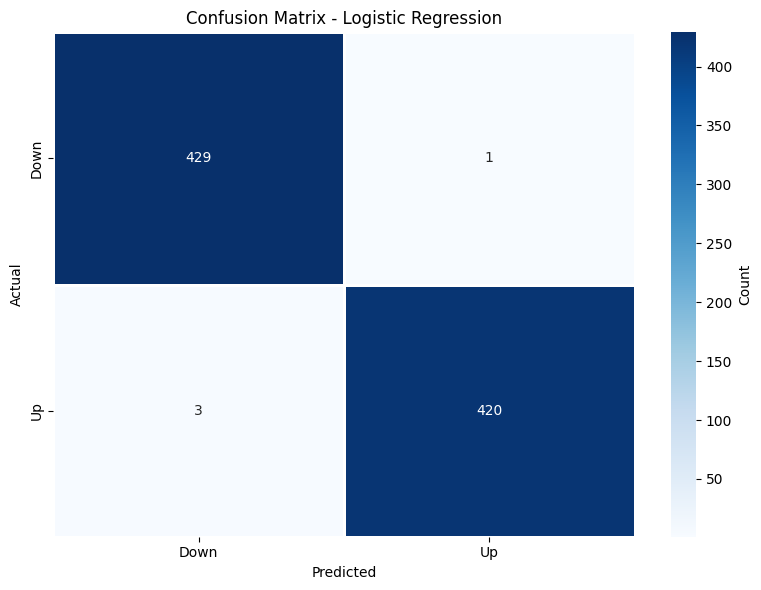

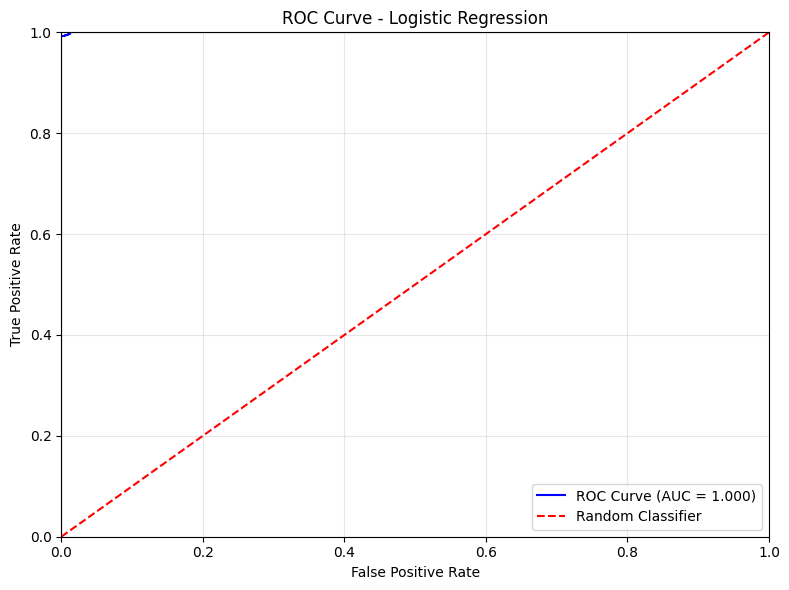

In [ ]:
import pandas as pd
import numpy as np
import pickle
import csv
from typing import Tuple, Dict, Any, Optional
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, accuracy_score, f1_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


class SquatPostureMLPipeline:
    """
    Complete ML Pipeline for Squat Posture Detection using Logistic Regression
    """

    def __init__(self, random_state: int = 1234):
        """
        Initialize the ML pipeline

        Args:
            random_state: Random state for reproducibility
        """
        self.random_state = random_state
        self.model = None
        self.scaler = None
        self.is_trained = False
        self.feature_names = None
        self.label_mapping = {'down': 0, 'up': 1}

        # Important landmarks for squat detection
        self.important_landmarks = [
            "NOSE", "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP",
            "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE"
        ]

        # Generate column names
        self.columns = self._generate_column_names()

    def _generate_column_names(self) -> list:
        """Generate column names for the dataset"""
        columns = ["label"]
        for lm in self.important_landmarks:
            columns.extend([
                f"{lm.lower()}_x", f"{lm.lower()}_y",
                f"{lm.lower()}_z", f"{lm.lower()}_v"
            ])
        return columns

    def load_data(self, filepath: str) -> pd.DataFrame:
        """
        Load data from CSV file

        Args:
            filepath: Path to the CSV file

        Returns:
            Loaded DataFrame
        """
        try:
            df = pd.read_csv(filepath)
            print(f"Data loaded successfully from {filepath}")
            print(f"Shape: {df.shape}")
            return df
        except Exception as e:
            print(f"Error loading data: {e}")
            raise

    def preprocess_data(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
        """
        Preprocess the data

        Args:
            df: Input DataFrame

        Returns:
            Tuple of (features, labels)
        """
        # Create a copy to avoid modifying original data
        df_processed = df.copy()

        # Convert string labels to numeric
        df_processed['label'] = df_processed['label'].map(self.label_mapping)

        # Separate features and labels
        X = df_processed.drop('label', axis=1)
        y = df_processed['label']

        # Store feature names
        self.feature_names = X.columns.tolist()

        print(f"Features shape: {X.shape}")
        print(f"Labels distribution:\n{y.value_counts()}")

        return X, y

    def split_data(self, X: pd.DataFrame, y: pd.Series,
                   test_size: float = 0.2) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
        """
        Split data into train and test sets

        Args:
            X: Features
            y: Labels
            test_size: Proportion of test data

        Returns:
            X_train, X_test, y_train, y_test
        """
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=self.random_state, stratify=y
        )

        print(f"Training set size: {X_train.shape[0]}")
        print(f"Test set size: {X_test.shape[0]}")

        return X_train, X_test, y_train, y_test

    def scale_features(self, X_train: pd.DataFrame, X_test: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Scale features using StandardScaler

        Args:
            X_train: Training features
            X_test: Test features

        Returns:
            Scaled training and test features
        """
        self.scaler = StandardScaler()

        # Fit scaler on training data and transform both sets
        X_train_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        X_test_scaled = pd.DataFrame(
            self.scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        print("Features scaled successfully")
        return X_train_scaled, X_test_scaled

    def train_model(self, X_train: pd.DataFrame, y_train: pd.Series,
                    **model_params) -> LogisticRegression:
        """
        Train Logistic Regression model

        Args:
            X_train: Training features
            y_train: Training labels
            **model_params: Additional parameters for LogisticRegression

        Returns:
            Trained model
        """
        # Default parameters
        default_params = {
            'random_state': self.random_state,
            'max_iter': 1000
        }
        default_params.update(model_params)

        # Initialize and train model
        self.model = LogisticRegression(**default_params)
        self.model.fit(X_train, y_train)

        self.is_trained = True
        print("Model trained successfully")

        return self.model

    def evaluate_model(self, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, Any]:
        """
        Evaluate the trained model

        Args:
            X_test: Test features
            y_test: Test labels

        Returns:
            Dictionary containing evaluation metrics
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before evaluation")

        # Make predictions
        y_pred = self.model.predict(X_test)
        y_pred_proba = self.model.predict_proba(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average=None, labels=[0, 1])
        recall = recall_score(y_test, y_pred, average=None, labels=[0, 1])
        f1 = f1_score(y_test, y_pred, average=None, labels=[0, 1])
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        # ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
        roc_auc = auc(fpr, tpr)

        # Find optimal threshold
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]

        results = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm,
            'roc_auc': roc_auc,
            'optimal_threshold': optimal_threshold,
            'fpr': fpr,
            'tpr': tpr,
            'thresholds': thresholds,
            'predictions': y_pred,
            'prediction_probabilities': y_pred_proba
        }

        return results

    def print_evaluation_summary(self, results: Dict[str, Any]):
        """
        Print evaluation summary

        Args:
            results: Results dictionary from evaluate_model
        """
        print("\n" + "="*50)
        print("LOGISTIC REGRESSION MODEL EVALUATION")
        print("="*50)

        print(f"Accuracy: {results['accuracy']:.4f}")
        print(f"ROC AUC: {results['roc_auc']:.4f}")
        print(f"Optimal Threshold: {results['optimal_threshold']:.4f}")

        print("\nClass-wise Metrics:")
        print(f"{'Class':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
        print("-" * 40)
        classes = ['Down', 'Up']
        for i, class_name in enumerate(classes):
            print(f"{class_name:<10} {results['precision'][i]:<10.4f} "
                  f"{results['recall'][i]:<10.4f} {results['f1_score'][i]:<10.4f}")

        print(f"\nConfusion Matrix:")
        print(f"{'Predicted':<12} {'Down':<8} {'Up':<8}")
        print("-" * 28)
        print(f"{'Actual Down':<12} {results['confusion_matrix'][0][0]:<8} {results['confusion_matrix'][0][1]:<8}")
        print(f"{'Actual Up':<12} {results['confusion_matrix'][1][0]:<8} {results['confusion_matrix'][1][1]:<8}")

    def plot_confusion_matrix(self, results: Dict[str, Any]):
        """
        Plot confusion matrix heatmap

        Args:
            results: Results dictionary from evaluate_model
        """
        plt.figure(figsize=(8, 6))
        cm_df = pd.DataFrame(
            results['confusion_matrix'],
            index=['Down', 'Up'],
            columns=['Down', 'Up']
        )

        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
                   linewidths=1, cbar_kws={'label': 'Count'})
        plt.title('Confusion Matrix - Logistic Regression')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self, results: Dict[str, Any]):
        """
        Plot ROC curve

        Args:
            results: Results dictionary from evaluate_model
        """
        plt.figure(figsize=(8, 6))
        plt.plot(results['fpr'], results['tpr'], 'b',
                label=f'ROC Curve (AUC = {results["roc_auc"]:.3f})')
        plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')

        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - Logistic Regression')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_threshold_analysis(self, X_test: pd.DataFrame, y_test: pd.Series):
        """
        Plot F1 score vs threshold analysis

        Args:
            X_test: Test features
            y_test: Test labels
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before threshold analysis")

        y_pred_proba = self.model.predict_proba(X_test)
        thresholds = np.arange(0.1, 1.0, 0.01)

        f1_scores_class0 = []
        f1_scores_class1 = []
        f1_scores_weighted = []

        for threshold in thresholds:
            y_pred_thresh = (y_pred_proba[:, 1] >= threshold).astype(int)

            # Calculate F1 scores
            f1_class = f1_score(y_test, y_pred_thresh, average=None, labels=[0, 1])
            f1_weighted = f1_score(y_test, y_pred_thresh, average='weighted')

            f1_scores_class0.append(f1_class[0] if len(f1_class) > 0 else 0)
            f1_scores_class1.append(f1_class[1] if len(f1_class) > 1 else 0)
            f1_scores_weighted.append(f1_weighted)

        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, f1_scores_class0, label='F1 Score - Down', linewidth=2)
        plt.plot(thresholds, f1_scores_class1, label='F1 Score - Up', linewidth=2)
        plt.plot(thresholds, f1_scores_weighted, label='F1 Score - Weighted',
                linewidth=2, color='blue')

        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.title('F1 Score vs Classification Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim([0.1, 1.0])
        plt.ylim([0, 1])
        plt.tight_layout()
        plt.show()

    def predict(self, X: pd.DataFrame, threshold: Optional[float] = None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Make predictions on new data

        Args:
            X: Features to predict
            threshold: Optional custom threshold

        Returns:
            Tuple of (predictions, probabilities)
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before making predictions")

        # Scale features
        X_scaled = pd.DataFrame(
            self.scaler.transform(X),
            columns=X.columns,
            index=X.index
        )

        # Get probabilities
        probabilities = self.model.predict_proba(X_scaled)

        # Make predictions
        if threshold is None:
            predictions = self.model.predict(X_scaled)
        else:
            predictions = (probabilities[:, 1] >= threshold).astype(int)

        return predictions, probabilities

    def save_model(self, filepath: str):
        """
        Save the trained model and scaler

        Args:
            filepath: Path to save the model
        """
        if not self.is_trained:
            raise ValueError("Model must be trained before saving")

        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'label_mapping': self.label_mapping,
            'important_landmarks': self.important_landmarks
        }

        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)

        print(f"Model saved to {filepath}")

    def load_model(self, filepath: str):
        """
        Load a trained model

        Args:
            filepath: Path to the saved model
        """
        try:
            with open(filepath, 'rb') as f:
                model_data = pickle.load(f)

            self.model = model_data['model']
            self.scaler = model_data['scaler']
            self.feature_names = model_data['feature_names']
            self.label_mapping = model_data['label_mapping']
            self.important_landmarks = model_data['important_landmarks']
            self.is_trained = True

            print(f"Model loaded from {filepath}")

        except Exception as e:
            print(f"Error loading model: {e}")
            raise

    def run_complete_pipeline(self, train_filepath: str, test_filepath: Optional[str] = None,
                            test_size: float = 0.2, model_params: Optional[Dict] = None,
                            save_model_path: Optional[str] = None) -> Dict[str, Any]:
        """
        Run the complete ML pipeline

        Args:
            train_filepath: Path to training data
            test_filepath: Optional path to separate test data
            test_size: Test size if splitting from train data
            model_params: Optional model parameters
            save_model_path: Optional path to save the model

        Returns:
            Evaluation results
        """
        print("Starting Complete ML Pipeline for Squat Posture Detection")
        print("="*60)

        # Load data
        print("\n1. Loading Data...")
        train_df = self.load_data(train_filepath)

        # Preprocess data
        print("\n2. Preprocessing Data...")
        X, y = self.preprocess_data(train_df)

        # Split data or load separate test set
        if test_filepath:
            print("\n3. Loading separate test data...")
            test_df = self.load_data(test_filepath)
            X_test, y_test = self.preprocess_data(test_df)
            X_train, y_train = X, y
        else:
            print(f"\n3. Splitting data (test_size={test_size})...")
            X_train, X_test, y_train, y_test = self.split_data(X, y, test_size)

        # Scale features
        print("\n4. Scaling Features...")
        X_train_scaled, X_test_scaled = self.scale_features(X_train, X_test)

        # Train model
        print("\n5. Training Logistic Regression Model...")
        model_params = model_params or {}
        self.train_model(X_train_scaled, y_train, **model_params)

        # Evaluate model
        print("\n6. Evaluating Model...")
        results = self.evaluate_model(X_test_scaled, y_test)

        # Print results
        self.print_evaluation_summary(results)

        # Save model if requested
        if save_model_path:
            print(f"\n7. Saving Model to {save_model_path}...")
            self.save_model(save_model_path)

        print("\nPipeline completed successfully!")
        return results


# Example usage
if __name__ == "__main__":
    # Initialize pipeline
    pipeline = SquatPostureMLPipeline(random_state=1234)

    # Run complete pipeline
    results = pipeline.run_complete_pipeline(
        train_filepath="./train.csv",
        test_filepath="./test.csv",
        model_params={'C': 1.0, 'solver': 'liblinear'},
        save_model_path="./squat_lr_model.pkl"
    )

    # Plot visualizations
    pipeline.plot_confusion_matrix(results)
    pipeline.plot_roc_curve(results)

## Installing dependencies

In [ ]:
!pip install mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 27.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
grpcio

## Real-time Detection

In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
import pickle
from typing import Dict, Any, Optional, Tuple, List

# MediaPipe setup
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

class SquatAnalyzerRealtime:
    def __init__(self, model_path: str):
        """
        Initialize the real-time squat analyzer

        Args:
            model_path: Path to the trained pkl model
        """
        self.model_path = model_path
        self.model = None
        self.scaler = None
        self.feature_names = None
        self.load_model()

        # Counter and stage tracking
        self.counter = 0
        self.current_stage = ""

        # Thresholds
        self.PREDICTION_PROB_THRESHOLD = 0.7
        self.VISIBILITY_THRESHOLD = 0.6
        self.FOOT_SHOULDER_RATIO_THRESHOLDS = [1.2, 2.8]
        self.KNEE_FOOT_RATIO_THRESHOLDS = {
            "up": [0.5, 1.0],
            "middle": [0.7, 1.0],
            "down": [0.7, 1.1],
        }

        # Warning messages
        self.warnings = []

    def load_model(self):
        """Load the trained model and scaler"""
        try:
            with open(self.model_path, 'rb') as f:
                model_data = pickle.load(f)

            self.model = model_data['model']
            self.scaler = model_data['scaler']
            self.feature_names = model_data.get('feature_names', None)
            print(f"Model loaded successfully from {self.model_path}")

        except Exception as e:
            print(f"Error loading model: {e}")
            raise

    def extract_important_keypoints(self, results) -> list:
        """
        Extract important keypoints for squat analysis

        Args:
            results: MediaPipe pose results

        Returns:
            List of keypoint coordinates
        """
        if not results.pose_landmarks:
            return None

        landmarks = results.pose_landmarks.landmark

        # Important landmarks for squat detection
        important_landmarks = [
            mp_pose.PoseLandmark.NOSE,
            mp_pose.PoseLandmark.LEFT_SHOULDER,
            mp_pose.PoseLandmark.RIGHT_SHOULDER,
            mp_pose.PoseLandmark.LEFT_HIP,
            mp_pose.PoseLandmark.RIGHT_HIP,
            mp_pose.PoseLandmark.LEFT_KNEE,
            mp_pose.PoseLandmark.RIGHT_KNEE,
            mp_pose.PoseLandmark.LEFT_ANKLE,
            mp_pose.PoseLandmark.RIGHT_ANKLE
        ]

        row = []
        for landmark in important_landmarks:
            lm = landmarks[landmark.value]
            row.extend([lm.x, lm.y, lm.z, lm.visibility])

        return row

    @staticmethod
    def calculate_distance(pointX: List[float], pointY: List[float]) -> float:
        """
        Calculate Euclidean distance between 2 points

        Args:
            pointX: First point [x, y]
            pointY: Second point [x, y]

        Returns:
            Distance between the points
        """
        x1, y1 = pointX
        x2, y2 = pointY
        return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    def analyze_foot_knee_placement(self, results, stage: str) -> Dict[str, int]:
        """
        Analyze foot and knee placement (following actual code logic)

        Args:
            results: MediaPipe pose results
            stage: Current squat stage ('up', 'middle', 'down')

        Returns:
            Dictionary with placement evaluations:
                -1: Unknown result due to poor visibility
                0: Correct placement
                1: Placement too tight
                2: Placement too wide
        """
        analyzed_results = {
            "foot_placement": -1,
            "knee_placement": -1,
        }

        if not results.pose_landmarks:
            return analyzed_results

        landmarks = results.pose_landmarks.landmark

        # Visibility check of important landmarks (as in actual code)
        left_foot_index_vis = landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].visibility
        right_foot_index_vis = landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].visibility
        left_knee_vis = landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].visibility
        right_knee_vis = landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].visibility

        # If visibility of any keypoints is low cancel the analysis
        if (left_foot_index_vis < self.VISIBILITY_THRESHOLD or
            right_foot_index_vis < self.VISIBILITY_THRESHOLD or
            left_knee_vis < self.VISIBILITY_THRESHOLD or
            right_knee_vis < self.VISIBILITY_THRESHOLD):
            return analyzed_results

        # Calculate shoulder width (as in actual code)
        left_shoulder = [
            landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y
        ]
        right_shoulder = [
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y
        ]
        shoulder_width = self.calculate_distance(left_shoulder, right_shoulder)

        # Calculate 2-foot width (as in actual code)
        left_foot_index = [
            landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].y
        ]
        right_foot_index = [
            landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].y
        ]
        foot_width = self.calculate_distance(left_foot_index, right_foot_index)

        # Calculate foot and shoulder ratio (as in actual code)
        foot_shoulder_ratio = round(foot_width / shoulder_width, 1)

        # Analyze FOOT PLACEMENT (as in actual code)
        min_ratio_foot_shoulder, max_ratio_foot_shoulder = self.FOOT_SHOULDER_RATIO_THRESHOLDS
        if min_ratio_foot_shoulder <= foot_shoulder_ratio <= max_ratio_foot_shoulder:
            analyzed_results["foot_placement"] = 0
        elif foot_shoulder_ratio < min_ratio_foot_shoulder:
            analyzed_results["foot_placement"] = 1
        elif foot_shoulder_ratio > max_ratio_foot_shoulder:
            analyzed_results["foot_placement"] = 2

        # Re-check knee visibility (as in actual code)
        left_knee_vis = landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].visibility
        right_knee_vis = landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].visibility

        if (left_knee_vis < self.VISIBILITY_THRESHOLD or
            right_knee_vis < self.VISIBILITY_THRESHOLD):
            return analyzed_results

        # Calculate 2 knee width (as in actual code)
        left_knee = [
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y
        ]
        right_knee = [
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y
        ]
        knee_width = self.calculate_distance(left_knee, right_knee)

        # Calculate knee and foot ratio (as in actual code)
        knee_foot_ratio = round(knee_width / foot_width, 1)

        # Analyze KNEE placement (as in actual code)
        if stage == "up":
            min_ratio, max_ratio = self.KNEE_FOOT_RATIO_THRESHOLDS.get("up", [0.5, 1.0])
        elif stage == "middle":
            min_ratio, max_ratio = self.KNEE_FOOT_RATIO_THRESHOLDS.get("middle", [0.7, 1.0])
        elif stage == "down":
            min_ratio, max_ratio = self.KNEE_FOOT_RATIO_THRESHOLDS.get("down", [0.7, 1.1])
        else:
            min_ratio, max_ratio = 0, 0  # Unknown stage

        if min_ratio <= knee_foot_ratio <= max_ratio:
            analyzed_results["knee_placement"] = 0
        elif knee_foot_ratio < min_ratio:
            analyzed_results["knee_placement"] = 1
        elif knee_foot_ratio > max_ratio:
            analyzed_results["knee_placement"] = 2

        return analyzed_results

    def generate_warnings(self, foot_placement: int, knee_placement: int,
                         prediction_probability: float) -> List[str]:
        """
        Generate warning messages based on analysis (expanded from actual code)

        Args:
            foot_placement: Foot placement evaluation code (-1, 0, 1, 2)
            knee_placement: Knee placement evaluation code (-1, 0, 1, 2)
            prediction_probability: Model prediction confidence

        Returns:
            List of warning messages
        """
        warnings = []

        # Low confidence warning
        if prediction_probability < self.PREDICTION_PROB_THRESHOLD:
            warnings.append("LOW CONFIDENCE - Check posture")

        # Foot placement warnings (matching actual code evaluation)
        if foot_placement == 1:
            warnings.append("WARNING: FEET TOO CLOSE")
        elif foot_placement == 2:
            warnings.append("WARNING: FEET TOO WIDE")

        # Knee placement warnings (matching actual code evaluation)
        if knee_placement == 1:
            warnings.append("WARNING: KNEES CAVING IN")
        elif knee_placement == 2:
            warnings.append("WARNING: KNEES TOO WIDE")

        return warnings

    def draw_interface(self, image: np.ndarray, predicted_class: str,
                      prediction_probability: float, analyzed_results: Dict[str, int]) -> np.ndarray:
        """
        Draw the user interface on the image with extended black title box and centered warnings

        Args:
            image: Input image
            predicted_class: Predicted squat stage
            prediction_probability: Prediction confidence
            analyzed_results: Dictionary with foot_placement and knee_placement codes

        Returns:
            Image with interface drawn
        """
        height, width = image.shape[:2]

        # Create extended black title box (now includes metrics)
        title_box_height = 100  # Increased height to include metrics
        cv2.rectangle(image, (0, 0), (width, title_box_height), (0, 0, 0), -1)

        # Add "Squat Analyzer" title in white
        (title_width, title_height), _ = cv2.getTextSize("SQUAT ANALYZER", cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
        title_x = (width - title_width) // 2
        cv2.putText(image, "SQUAT ANALYZER", (title_x, 40),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

        # Display counter and stage in the extended black area
        counter_text = f"COUNT: {self.counter}"
        stage_text = f"STAGE: {predicted_class.upper()}"

        # Prepare counter and stage text
        counter_text = f"COUNT: {self.counter}"
        stage_text = f"STAGE: {predicted_class.upper()}"

        # Calculate text sizes
        (counter_width, counter_height), _ = cv2.getTextSize(counter_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        (stage_width, stage_height), _ = cv2.getTextSize(stage_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)

        # Calculate vertical positions to center both lines in the remaining box space
        total_text_height = counter_height + stage_height + 10  # 10px gap between lines
        start_y = title_box_height // 2 + 15  # Start below title

        # Draw counter text (centered horizontally and vertically)
        counter_x = (width - counter_width) // 2
        cv2.putText(image, counter_text, (counter_x, start_y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        # Draw stage text (centered horizontally and vertically)
        stage_x = (width - stage_width) // 2
        cv2.putText(image, stage_text, (stage_x, start_y + counter_height + 10),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        # Generate warnings based on analysis
        warnings = self.generate_warnings(
            analyzed_results["foot_placement"],
            analyzed_results["knee_placement"],
            prediction_probability
        )

        # Display warnings in center of screen (big red text)
        if warnings:
            warning_y = height // 2
            for warning in warnings:
                (text_width, text_height), _ = cv2.getTextSize(warning, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 3)
                text_x = (width - text_width) // 2
                cv2.putText(image, warning, (text_x, warning_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3, cv2.LINE_AA)
                warning_y += 60  # Move down for next warning

        return image

    def run(self):
        """Run the real-time squat analyzer"""
        # Initialize camera
        cap = cv2.VideoCapture(0)

        if not cap.isOpened():
            print("Error: Could not open camera")
            return

        # Set camera properties for better performance
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
        cap.set(cv2.CAP_PROP_FPS, 30)

        print("Squat Analyzer started. Press 'q' to quit, 'r' to reset counter.")

        with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
            while cap.isOpened():
                ret, image = cap.read()

                if not ret:
                    print("Failed to capture frame")
                    break

                # Flip image horizontally for mirror effect
                image = cv2.flip(image, 1)

                # Convert BGR to RGB for MediaPipe
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image_rgb.flags.writeable = False

                # Process pose
                results = pose.process(image_rgb)

                # Convert back to BGR
                image_rgb.flags.writeable = True
                image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

                if results.pose_landmarks:
                    # Draw pose landmarks
                    mp_drawing.draw_landmarks(
                        image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                        mp_drawing.DrawingSpec(color=(244, 117, 66), thickness=2, circle_radius=2),
                        mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=1)
                    )

                    try:
                        # Extract keypoints and make prediction
                        row = self.extract_important_keypoints(results)

                        if row is not None:
                            # Create DataFrame for prediction
                            X = pd.DataFrame([row], columns=self.feature_names)

                            # Scale features
                            X_scaled = self.scaler.transform(X)

                            # Make prediction
                            predicted_class_num = self.model.predict(X_scaled)[0]
                            predicted_class = "down" if predicted_class_num == 0 else "up"

                            # Handle predict_proba if available, otherwise use default confidence
                            if hasattr(self.model, 'predict_proba'):
                                prediction_probabilities = self.model.predict_proba(X_scaled)[0]
                                prediction_probability = prediction_probabilities[prediction_probabilities.argmax()]
                            else:
                                prediction_probability = 1.0  # Default confidence if no proba available

                            # Update counter logic
                            if (predicted_class == "down" and
                                prediction_probability >= self.PREDICTION_PROB_THRESHOLD):
                                self.current_stage = "down"
                            elif (self.current_stage == "down" and predicted_class == "up" and
                                  prediction_probability >= self.PREDICTION_PROB_THRESHOLD):
                                self.current_stage = "up"
                                self.counter += 1

                            # Analyze pose
                            analyzed_results = self.analyze_foot_knee_placement(results, self.current_stage)

                            # Draw interface
                            image = self.draw_interface(
                                image, predicted_class, prediction_probability, analyzed_results
                            )

                    except Exception as e:
                        print(f"Error during prediction: {e}")
                        # Draw basic interface with error state
                        error_results = {"foot_placement": -1, "knee_placement": -1}
                        image = self.draw_interface(image, "ERROR", 0.0, error_results)

                else:
                    # No pose detected
                    error_results = {"foot_placement": -1, "knee_placement": -1}
                    image = self.draw_interface(image, "NO POSE", 0.0, error_results)

                # Display the image
                cv2.imshow('Squat Analyzer - Real-time', image)

                # Handle key presses
                key = cv2.waitKey(1) & 0xFF
                if key == ord('q'):
                    break
                elif key == ord('r'):
                    self.counter = 0
                    self.current_stage = ""
                    print("Counter reset")

        # Cleanup
        cap.release()
        cv2.destroyAllWindows()


if __name__ == "__main__":
    # Initialize and run the analyzer
    analyzer = SquatAnalyzerRealtime(model_path="./model/squat_lr_model.pkl")
    analyzer.run()

Model loaded successfully from ./squat_lr_model.pkl
Error: Could not open camera


## Video Input Detection

In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
import pickle
from typing import Dict, Any, Optional, Tuple, List
import os
import math

# MediaPipe setup
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

class SquatAnalyzerVideo:
    def __init__(self, model_path: str):
        """
        Initialize the video squat analyzer

        Args:
            model_path: Path to the trained pkl model
        """
        self.model_path = model_path
        self.model = None
        self.scaler = None  # Add scaler attribute
        self.headers = None
        self.load_model()

        # Counter and stage tracking
        self.counter = 0
        self.current_stage = ""

        # Thresholds (from actual code)
        self.PREDICTION_PROB_THRESHOLD = 0.7
        self.VISIBILITY_THRESHOLD = 0.6
        self.FOOT_SHOULDER_RATIO_THRESHOLDS = [1.2, 2.8]
        self.KNEE_FOOT_RATIO_THRESHOLDS = {
            "up": [0.5, 1.0],
            "middle": [0.7, 1.0],
            "down": [0.7, 1.1],
        }

        # Warning messages
        self.warnings = []

    def load_model(self):
        """Load the trained model and feature headers"""
        try:
            with open(self.model_path, 'rb') as f:
                model_data = pickle.load(f)  # Load the dictionary

            # Extract the actual model and scaler from the dictionary
            self.model = model_data.get('model')
            self.scaler = model_data.get('scaler')

            # Set headers based on expected features
            self.headers = [
                'class',
                'nose_x', 'nose_y', 'nose_z', 'nose_v',
                'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_shoulder_v',
                'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_shoulder_v',
                'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_hip_v',
                'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_hip_v',
                'left_knee_x', 'left_knee_y', 'left_knee_z', 'left_knee_v',
                'right_knee_x', 'right_knee_y', 'right_knee_z', 'right_knee_v',
                'left_ankle_x', 'left_ankle_y', 'left_ankle_z', 'left_ankle_v',
                'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'right_ankle_v'
            ]

            print(f"Model loaded successfully from {self.model_path}")

        except Exception as e:
            print(f"Error loading model: {e}")
            raise

    @staticmethod
    def calculate_distance(pointX: List[float], pointY: List[float]) -> float:
        """
        Calculate Euclidean distance between 2 points (from actual code)

        Args:
            pointX: First point [x, y]
            pointY: Second point [x, y]

        Returns:
            Distance between the points
        """
        x1, y1 = pointX
        x2, y2 = pointY
        return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    def extract_important_keypoints(self, results) -> list:
        """
        Extract important keypoints for squat analysis (similar to actual code)

        Args:
            results: MediaPipe pose results

        Returns:
            List of keypoint coordinates
        """
        if not results.pose_landmarks:
            return None

        landmarks = results.pose_landmarks.landmark

        # Important landmarks for squat detection (as in actual code)
        important_landmarks = [
            mp_pose.PoseLandmark.NOSE,
            mp_pose.PoseLandmark.LEFT_SHOULDER,
            mp_pose.PoseLandmark.RIGHT_SHOULDER,
            mp_pose.PoseLandmark.LEFT_HIP,
            mp_pose.PoseLandmark.RIGHT_HIP,
            mp_pose.PoseLandmark.LEFT_KNEE,
            mp_pose.PoseLandmark.RIGHT_KNEE,
            mp_pose.PoseLandmark.LEFT_ANKLE,
            mp_pose.PoseLandmark.RIGHT_ANKLE
        ]

        row = []
        for landmark in important_landmarks:
            lm = landmarks[landmark.value]
            row.extend([lm.x, lm.y, lm.z, lm.visibility])

        return row

    def analyze_foot_knee_placement(self, results, stage: str) -> Dict[str, int]:
        """
        Analyze foot and knee placement (following actual code logic)

        Args:
            results: MediaPipe pose results
            stage: Current squat stage ('up', 'middle', 'down')

        Returns:
            Dictionary with placement evaluations:
                -1: Unknown result due to poor visibility
                0: Correct placement
                1: Placement too tight
                2: Placement too wide
        """
        analyzed_results = {
            "foot_placement": -1,
            "knee_placement": -1,
        }

        if not results.pose_landmarks:
            return analyzed_results

        landmarks = results.pose_landmarks.landmark

        # Visibility check of important landmarks (as in actual code)
        left_foot_index_vis = landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].visibility
        right_foot_index_vis = landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].visibility
        left_knee_vis = landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].visibility
        right_knee_vis = landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].visibility

        # If visibility of any keypoints is low cancel the analysis
        if (left_foot_index_vis < self.VISIBILITY_THRESHOLD or
            right_foot_index_vis < self.VISIBILITY_THRESHOLD or
            left_knee_vis < self.VISIBILITY_THRESHOLD or
            right_knee_vis < self.VISIBILITY_THRESHOLD):
            return analyzed_results

        # Calculate shoulder width (as in actual code)
        left_shoulder = [
            landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y
        ]
        right_shoulder = [
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y
        ]
        shoulder_width = self.calculate_distance(left_shoulder, right_shoulder)

        # Calculate 2-foot width (as in actual code)
        left_foot_index = [
            landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value].y
        ]
        right_foot_index = [
            landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value].y
        ]
        foot_width = self.calculate_distance(left_foot_index, right_foot_index)

        # Calculate foot and shoulder ratio (as in actual code)
        foot_shoulder_ratio = round(foot_width / shoulder_width, 1)

        # Analyze FOOT PLACEMENT (as in actual code)
        min_ratio_foot_shoulder, max_ratio_foot_shoulder = self.FOOT_SHOULDER_RATIO_THRESHOLDS
        if min_ratio_foot_shoulder <= foot_shoulder_ratio <= max_ratio_foot_shoulder:
            analyzed_results["foot_placement"] = 0
        elif foot_shoulder_ratio < min_ratio_foot_shoulder:
            analyzed_results["foot_placement"] = 1
        elif foot_shoulder_ratio > max_ratio_foot_shoulder:
            analyzed_results["foot_placement"] = 2

        # Re-check knee visibility (as in actual code)
        left_knee_vis = landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].visibility
        right_knee_vis = landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].visibility

        if (left_knee_vis < self.VISIBILITY_THRESHOLD or
            right_knee_vis < self.VISIBILITY_THRESHOLD):
            return analyzed_results

        # Calculate 2 knee width (as in actual code)
        left_knee = [
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y
        ]
        right_knee = [
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y
        ]
        knee_width = self.calculate_distance(left_knee, right_knee)

        # Calculate knee and foot ratio (as in actual code)
        knee_foot_ratio = round(knee_width / foot_width, 1)

        # Analyze KNEE placement (as in actual code)
        if stage == "up":
            min_ratio, max_ratio = self.KNEE_FOOT_RATIO_THRESHOLDS.get("up", [0.5, 1.0])
        elif stage == "middle":
            min_ratio, max_ratio = self.KNEE_FOOT_RATIO_THRESHOLDS.get("middle", [0.7, 1.0])
        elif stage == "down":
            min_ratio, max_ratio = self.KNEE_FOOT_RATIO_THRESHOLDS.get("down", [0.7, 1.1])
        else:
            min_ratio, max_ratio = 0, 0  # Unknown stage

        if min_ratio <= knee_foot_ratio <= max_ratio:
            analyzed_results["knee_placement"] = 0
        elif knee_foot_ratio < min_ratio:
            analyzed_results["knee_placement"] = 1
        elif knee_foot_ratio > max_ratio:
            analyzed_results["knee_placement"] = 2

        return analyzed_results

    def generate_warnings(self, foot_placement: int, knee_placement: int,
                         prediction_probability: float) -> List[str]:
        """
        Generate warning messages based on analysis (expanded from actual code)

        Args:
            foot_placement: Foot placement evaluation code (-1, 0, 1, 2)
            knee_placement: Knee placement evaluation code (-1, 0, 1, 2)
            prediction_probability: Model prediction confidence

        Returns:
            List of warning messages
        """
        warnings = []

        # Low confidence warning
        if prediction_probability < self.PREDICTION_PROB_THRESHOLD:
            warnings.append("LOW CONFIDENCE - Check posture")

        # Foot placement warnings (matching actual code evaluation)
        if foot_placement == 1:
            warnings.append("FEET TOO CLOSE - Widen stance")
        elif foot_placement == 2:
            warnings.append("FEET TOO WIDE - Narrow stance")
        elif foot_placement == -1:
            warnings.append("FOOT PLACEMENT UNKNOWN - Ensure feet are visible")

        # Knee placement warnings (matching actual code evaluation)
        if knee_placement == 1:
            warnings.append("KNEES CAVING IN - Push knees out")
        elif knee_placement == 2:
            warnings.append("KNEES TOO WIDE - Align with feet")
        elif knee_placement == -1:
            warnings.append("KNEE PLACEMENT UNKNOWN - Ensure knees are visible")

        return warnings

    def draw_interface(self, image: np.ndarray, predicted_class: str,
                  prediction_probability: float, analyzed_results: Dict[str, int]) -> np.ndarray:
        """
        Draw the user interface on the image with extended black title box and centered warnings

        Args:
            image: Input image
            predicted_class: Predicted squat stage
            prediction_probability: Prediction confidence
            analyzed_results: Dictionary with foot_placement and knee_placement codes

        Returns:
            Image with interface drawn
        """
        height, width = image.shape[:2]

        # Create extended black title box (now includes metrics)
        title_box_height = 100  # Increased height to include metrics
        cv2.rectangle(image, (0, 0), (width, title_box_height), (0, 0, 0), -1)

        # Add "Squat Analyzer" title in white
        (title_width, title_height), _ = cv2.getTextSize("SQUAT ANALYZER", cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
        title_x = (width - title_width) // 2
        cv2.putText(image, "SQUAT ANALYZER", (title_x, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

        # Display counter and stage in the extended black area
        counter_text = f"COUNT: {self.counter}"
        stage_text = f"STAGE: {predicted_class.upper()}"

        # Prepare counter and stage text
        counter_text = f"COUNT: {self.counter}"
        stage_text = f"STAGE: {predicted_class.upper()}"

        # Calculate text sizes
        (counter_width, counter_height), _ = cv2.getTextSize(counter_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        (stage_width, stage_height), _ = cv2.getTextSize(stage_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)

        # Calculate vertical positions to center both lines in the remaining box space
        total_text_height = counter_height + stage_height + 10  # 10px gap between lines
        start_y = title_box_height // 2 + 15  # Start below title

        # Draw counter text (centered horizontally and vertically)
        counter_x = (width - counter_width) // 2
        cv2.putText(image, counter_text, (counter_x, start_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        # Draw stage text (centered horizontally and vertically)
        stage_x = (width - stage_width) // 2
        cv2.putText(image, stage_text, (stage_x, start_y + counter_height + 10),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        # Generate warnings based on analysis
        warnings = []

        # Foot placement warnings
        if analyzed_results["foot_placement"] == 1:
            warnings.append("WARNING: FEET TOO CLOSE")
        elif analyzed_results["foot_placement"] == 2:
            warnings.append("WARNING: FEET TOO WIDE")

        # Knee placement warnings
        if analyzed_results["knee_placement"] == 1:
            warnings.append("WARNING: KNEES CAVING IN")
        elif analyzed_results["knee_placement"] == 2:
            warnings.append("WARNING: KNEES TOO WIDE")

        # Display warnings in center of screen (big red text)
        if warnings:
            warning_y = height // 2
            for warning in warnings:
                (text_width, text_height), _ = cv2.getTextSize(warning, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 3)
                text_x = (width - text_width) // 2
                cv2.putText(image, warning, (text_x, warning_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3, cv2.LINE_AA)
                warning_y += 60  # Move down for next warning

        return image

    def process_video(self, input_path: str, output_path: str = None):
        """
        Process a video file and save the analyzed output

        Args:
            input_path: Path to input video file
            output_path: Path to save output video (optional)
        """
        if not os.path.exists(input_path):
            print(f"Error: Input video file '{input_path}' not found")
            return

        cap = cv2.VideoCapture(input_path)

        if not cap.isOpened():
            print(f"Error: Could not open video file '{input_path}'")
            return

        # Get video properties
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        # Set up output path
        if output_path is None:
            base_name = os.path.splitext(input_path)[0]
            output_path = f"{base_name}_analyzed.mp4"

        # Initialize video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        if not out.isOpened():
            print(f"Error: Could not create output video file '{output_path}'")
            cap.release()
            return

        print(f"Processing video: {input_path}")
        print(f"Output will be saved to: {output_path}")

        # Reset counter for new video
        self.counter = 0
        self.current_stage = ""

        with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
            while cap.isOpened():
                ret, image = cap.read()

                if not ret:
                    break

                # Convert BGR to RGB for MediaPipe
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image_rgb.flags.writeable = False

                # Process pose
                results = pose.process(image_rgb)

                # Convert back to BGR
                image_rgb.flags.writeable = True
                image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

                if results.pose_landmarks:
                    # Draw pose landmarks (as in actual code)
                    mp_drawing.draw_landmarks(
                        image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                        mp_drawing.DrawingSpec(color=(244, 117, 66), thickness=2, circle_radius=2),
                        mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=1)
                    )

                    try:
                        # Extract keypoints and make prediction (as in actual code)
                        row = self.extract_important_keypoints(results)

                        if row is not None:
                            # Create DataFrame for prediction (headers[1:] to skip 'class' column as in actual code)
                            X = pd.DataFrame([row], columns=self.headers[1:])

                                                        # Scale the features if scaler is available
                            if self.scaler:
                                X_scaled = self.scaler.transform(X)
                            else:
                                X_scaled = X

                            # Make prediction and its probability
                            predicted_class_num = self.model.predict(X_scaled)[0]
                            predicted_class = "down" if predicted_class_num == 0 else "up"

                            # Handle predict_proba if available, otherwise use default confidence
                            if hasattr(self.model, 'predict_proba'):
                                prediction_probabilities = self.model.predict_proba(X_scaled)[0]
                                prediction_probability = prediction_probabilities[prediction_probabilities.argmax()]
                            else:
                                prediction_probability = 1.0  # Default confidence if no proba available

                            # Update counter logic
                            if (predicted_class == "down" and
                                prediction_probability >= self.PREDICTION_PROB_THRESHOLD):
                                self.current_stage = "down"
                            elif (self.current_stage == "down" and predicted_class == "up" and
                                  prediction_probability >= self.PREDICTION_PROB_THRESHOLD):
                                self.current_stage = "up"
                                self.counter += 1

                            # Analyze pose
                            analyzed_results = self.analyze_foot_knee_placement(results, self.current_stage)

                            # Draw interface
                            image = self.draw_interface(
                                image, predicted_class, prediction_probability, analyzed_results
                            )

                    except Exception as e:
                        print(f"Error during prediction: {e}")
                        # Draw basic interface with error state
                        error_results = {"foot_placement": -1, "knee_placement": -1}
                        image = self.draw_interface(image, "ERROR", 0.0, error_results)

                # Write frame to output video
                out.write(image)

        # Cleanup
        cap.release()
        out.release()

        print(f"\nVideo processing complete!")
        print(f"Total squats detected: {self.counter}")
        print(f"Output saved to: {output_path}")


if __name__ == "__main__":
    # Initialize the analyzer
    analyzer = SquatAnalyzerVideo(model_path="./model/squat_lr_model.pkl")

    # Process video
    input_video = "squat-video.mp4"
    output_video = "squat_sample_analyzed.mp4"

    analyzer.process_video(input_video, output_video)